In [5]:
import pandas as pd

# Load the dataset
dataset_path = 'weatherHistory.csv'
data = pd.read_csv(dataset_path)

# Display the first few rows of the dataset to understand its structure
data.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [6]:
# Convert 'Formatted Date' to datetime and set as index
data['Formatted Date'] = pd.to_datetime(data['Formatted Date'], utc=True)
data.set_index('Formatted Date', inplace=True)

# Resample the data to daily averages to simplify the analysis
daily_data = data['Temperature (C)'].resample('D').mean()

# Display the first few rows of the resampled data
daily_data.head()

Formatted Date
2005-12-31 00:00:00+00:00    0.577778
2006-01-01 00:00:00+00:00    4.075000
2006-01-02 00:00:00+00:00    5.263194
2006-01-03 00:00:00+00:00    2.340509
2006-01-04 00:00:00+00:00    2.251852
Freq: D, Name: Temperature (C), dtype: float64

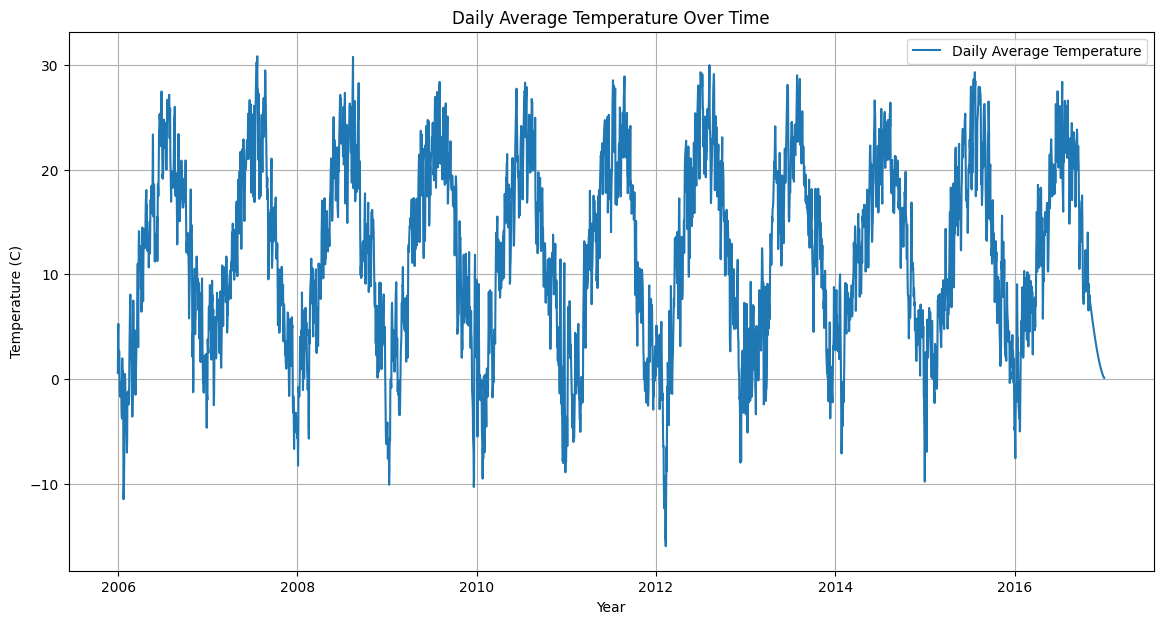

In [7]:
import matplotlib.pyplot as plt

# Plotting the daily average temperatures
plt.figure(figsize=(14, 7))
plt.plot(daily_data, label='Daily Average Temperature', color='tab:blue')
plt.title('Daily Average Temperature Over Time')
plt.xlabel('Year')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.show()


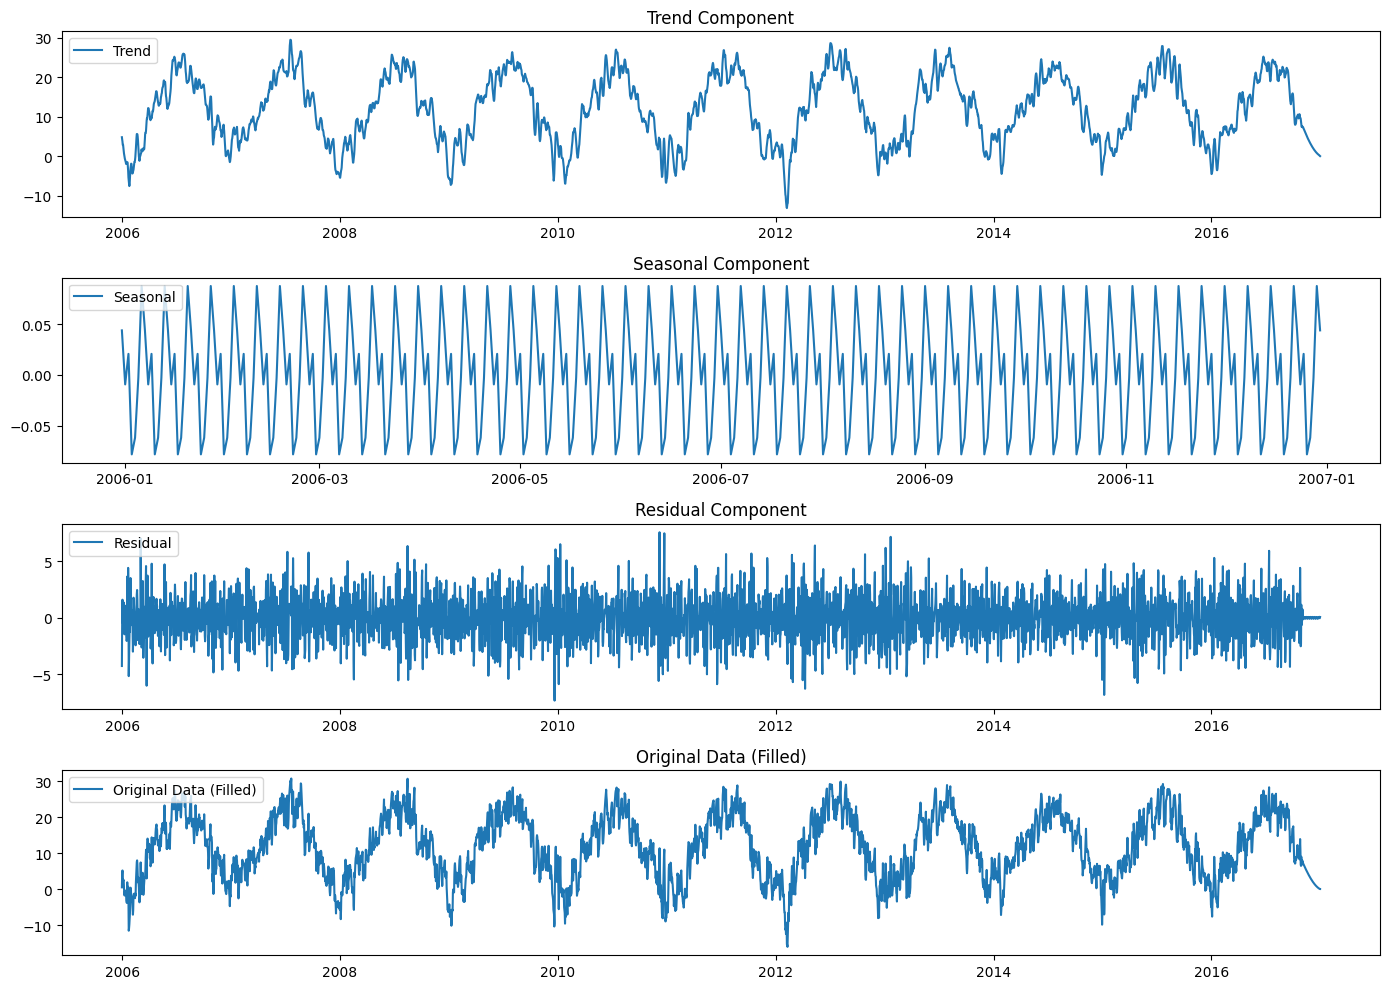

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Fill in missing values using forward fill
daily_data_filled = daily_data.fillna(method='ffill')

# Attempt the additive decomposition again with the filled data
decomposition_additive_filled = seasonal_decompose(daily_data_filled, model='additive', extrapolate_trend='freq')

# Plot the decomposed components of the time series
plt.figure(figsize=(14, 10))

# Trend component
plt.subplot(411)
plt.plot(decomposition_additive_filled.trend, label='Trend')
plt.legend(loc='upper left')
plt.title('Trend Component')

# Seasonal component
plt.subplot(412)
plt.plot(decomposition_additive_filled.seasonal.iloc[:365], label='Seasonal')  # Plotting one year of seasonal data for clarity
plt.legend(loc='upper left')
plt.title('Seasonal Component')

# Residual component
plt.subplot(413)
plt.plot(decomposition_additive_filled.resid, label='Residual')
plt.legend(loc='upper left')
plt.title('Residual Component')

# Original Data (with missing values filled)
plt.subplot(414)
plt.plot(daily_data_filled, label='Original Data (Filled)', color='tab:blue')
plt.legend(loc='upper left')
plt.title('Original Data (Filled)')

plt.tight_layout()
plt.show()
